In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

In [2]:
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_df = pd.read_csv(
    RAW_DATA_DIR / "application_train.csv"
)

In [3]:
selected_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "CODE_GENDER",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_INCOME_TYPE",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
]

In [4]:
X = train_df[selected_features].copy()
y = train_df["TARGET"].copy()

In [5]:
## Deterministic features handling.
def create_features(data: pd.DataFrame) -> pd.DataFrame:
    data = data.copy()

    data["AGE_YEARS"] = (
        -data["DAYS_BIRTH"] / 365.25
    )

    data["DAYS_EMPLOYED"] = (
        data["DAYS_EMPLOYED"]
        .replace(365243, np.nan)
    )

    data["CREDIT_INCOME_RATIO"] = (
        data["AMT_CREDIT"]
        / data["AMT_INCOME_TOTAL"].replace(0, np.nan)
    )

    data["ANNUITY_INCOME_RATIO"] = (
        data["AMT_ANNUITY"]
        / data["AMT_INCOME_TOTAL"].replace(0, np.nan)
    )

    data["CREDIT_TERM"] = (
        data["AMT_ANNUITY"]
        / data["AMT_CREDIT"].replace(0, np.nan)
    )

    data = data.drop(columns=["DAYS_BIRTH"])

    return data

In [6]:
X = create_features(X)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Model Pipeline

In [8]:
numeric_columns = X_train.select_dtypes(
    include="number"
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    exclude="number"
).columns.tolist()

In [9]:
numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler())
    ]
)

categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy = "most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_columns
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_columns
    )
])

In [10]:
dummy_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        DummyClassifier(
            strategy="prior"
        )
    )
])

In [11]:
dummy_scores = cross_val_score(
    dummy_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

dummy_scores.mean()

np.float64(0.5)

In [12]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [13]:
logistic_scores = cross_val_score(
    logistic_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print(logistic_scores)
print(logistic_scores.mean())
print(logistic_scores.std())

[0.74357484 0.73096118 0.74186467 0.74449645 0.74587032]
0.7413534913939985
0.005356785928066901


## Model Evaluation

In [14]:
logistic_pipeline.fit(
    X_train,
    y_train
)

y_prob = logistic_pipeline.predict_proba(
    X_test
)[:, 1]

y_pred = logistic_pipeline.predict(
    X_test
)

In [15]:
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report
)


In [16]:
print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

print(
    confusion_matrix(y_test, y_pred)
)

print(
    classification_report(y_test, y_pred)
)

Test ROC-AUC: 0.7440693329018578
[[38561 17977]
 [ 1585  3380]]
              precision    recall  f1-score   support

           0       0.96      0.68      0.80     56538
           1       0.16      0.68      0.26      4965

    accuracy                           0.68     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.68      0.75     61503



## Feature Importance

For the baseline logistic regression model, feature importance comes from the fitted coefficients after preprocessing. Positive coefficients push the prediction toward `TARGET = 1` default risk; negative coefficients push it toward `TARGET = 0` non-default. Because numeric features are standardized inside the pipeline, coefficient magnitudes are comparable across numeric features and one-hot encoded categories.

Top 25 features by absolute Logistic Regression coefficient
Interpretation: larger absolute coefficients have stronger influence in this baseline model.


,feature,coefficient,absolute_importance,direction,odds_multiplier
0,NAME_EDUCATION_TYPE_Academic degree,-1.0373,1.0373,decreases default risk,0.354
1,AMT_GOODS_PRICE,-1.0334,1.0334,decreases default risk,0.356
2,AMT_CREDIT,0.8489,0.8489,increases default risk,2.337
3,NAME_INCOME_TYPE_Pensioner,-0.6303,0.6303,decreases default risk,0.532
4,NAME_INCOME_TYPE_Unemployed,0.5423,0.5423,increases default risk,1.720
5,EXT_SOURCE_3,-0.5027,0.5027,decreases default risk,0.605
6,OCCUPATION_TYPE_IT staff,-0.4725,0.4725,decreases default risk,0.623
7,NAME_EDUCATION_TYPE_Lower secondary,0.4177,0.4177,increases default risk,1.518
8,EXT_SOURCE_2,-0.4162,0.4162,decreases default risk,0.660
9,OCCUPATION_TYPE_Low-skill Laborers,0.3845,0.3845,increases default risk,1.469


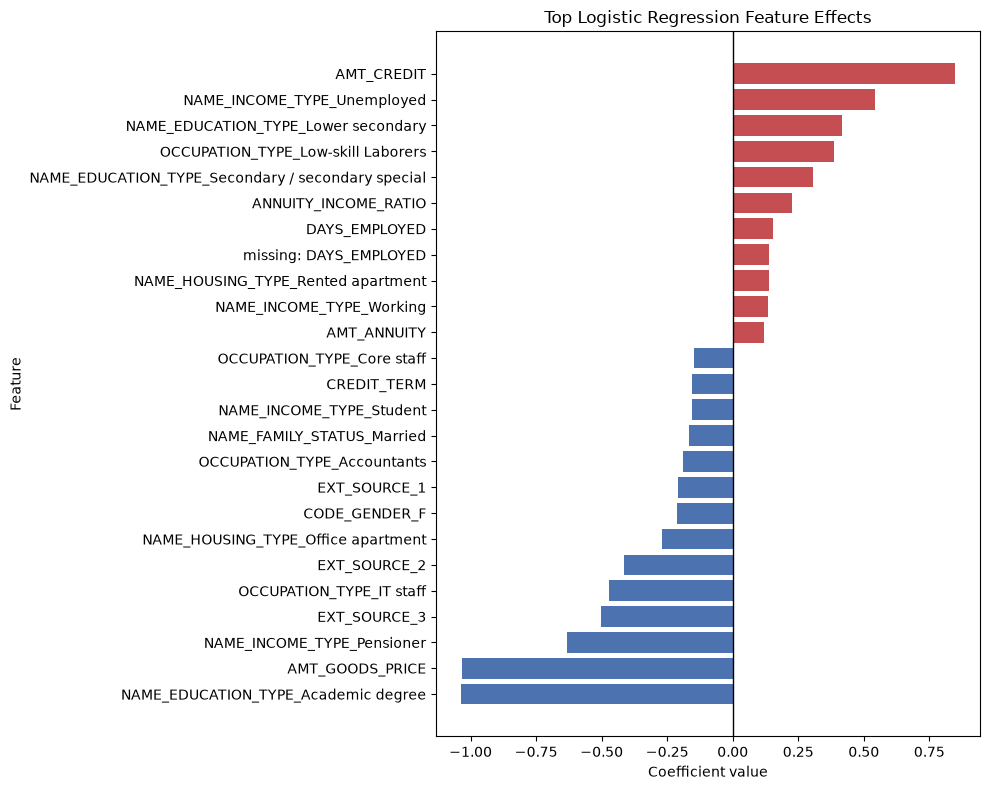

Most risk-increasing features:


,feature,coefficient,odds_multiplier
1,AMT_CREDIT,0.8489,2.337
43,NAME_INCOME_TYPE_Unemployed,0.5423,1.720
29,NAME_EDUCATION_TYPE_Lower secondary,0.4177,1.518
60,OCCUPATION_TYPE_Low-skill Laborers,0.3845,1.469
30,NAME_EDUCATION_TYPE_Secondary / secondary special,0.3054,1.357
12,ANNUITY_INCOME_RATIO,0.2244,1.252
4,DAYS_EMPLOYED,0.1535,1.166
16,missing: DAYS_EMPLOYED,0.1392,1.149
49,NAME_HOUSING_TYPE_Rented apartment,0.1385,1.149
44,NAME_INCOME_TYPE_Working,0.1357,1.145


Most risk-decreasing features:


,feature,coefficient,odds_multiplier
26,NAME_EDUCATION_TYPE_Academic degree,-1.0373,0.354
3,AMT_GOODS_PRICE,-1.0334,0.356
40,NAME_INCOME_TYPE_Pensioner,-0.6303,0.532
9,EXT_SOURCE_3,-0.5027,0.605
58,OCCUPATION_TYPE_IT staff,-0.4725,0.623
8,EXT_SOURCE_2,-0.4162,0.660
48,NAME_HOUSING_TYPE_Office apartment,-0.2686,0.764
23,CODE_GENDER_F,-0.2126,0.808
7,EXT_SOURCE_1,-0.2096,0.811
51,OCCUPATION_TYPE_Accountants,-0.1893,0.828


In [17]:
# Feature importance for the fitted Logistic Regression baseline
# Positive coefficient: increases predicted default risk.
# Negative coefficient: decreases predicted default risk.

feature_names = (
    logistic_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_pipeline
    .named_steps["model"]
    .coef_[0]
)

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
})

feature_importance_df["feature"] = (
    feature_importance_df["feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
    .str.replace("missingindicator_", "missing: ", regex=False)
)

feature_importance_df["absolute_importance"] = (
    feature_importance_df["coefficient"].abs()
)

feature_importance_df["direction"] = np.where(
    feature_importance_df["coefficient"] > 0,
    "increases default risk",
    "decreases default risk",
)

feature_importance_df["odds_multiplier"] = np.exp(
    feature_importance_df["coefficient"].clip(-20, 20)
)

top_features = (
    feature_importance_df
    .sort_values("absolute_importance", ascending=False)
    .head(25)
    .reset_index(drop=True)
)

print("Top 25 features by absolute Logistic Regression coefficient")
print("Interpretation: larger absolute coefficients have stronger influence in this baseline model.")

display(
    top_features.style.format({
        "coefficient": "{:.4f}",
        "absolute_importance": "{:.4f}",
        "odds_multiplier": "{:.3f}",
    })
)

plot_data = top_features.sort_values("coefficient")
colors = np.where(
    plot_data["coefficient"] > 0,
    "#c44e52",
    "#4c72b0",
)

plt.figure(figsize=(10, 8))
plt.barh(
    plot_data["feature"],
    plot_data["coefficient"],
    color=colors,
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Top Logistic Regression Feature Effects")
plt.xlabel("Coefficient value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Most risk-increasing features:")
display(
    feature_importance_df
    .sort_values("coefficient", ascending=False)
    .head(10)[["feature", "coefficient", "odds_multiplier"]]
    .style.format({
        "coefficient": "{:.4f}",
        "odds_multiplier": "{:.3f}",
    })
)

print("Most risk-decreasing features:")
display(
    feature_importance_df
    .sort_values("coefficient", ascending=True)
    .head(10)[["feature", "coefficient", "odds_multiplier"]]
    .style.format({
        "coefficient": "{:.4f}",
        "odds_multiplier": "{:.3f}",
    })
)


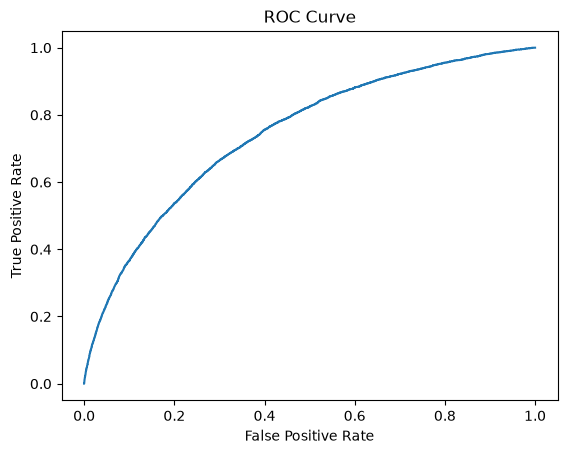

In [18]:
# draw the ROC curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

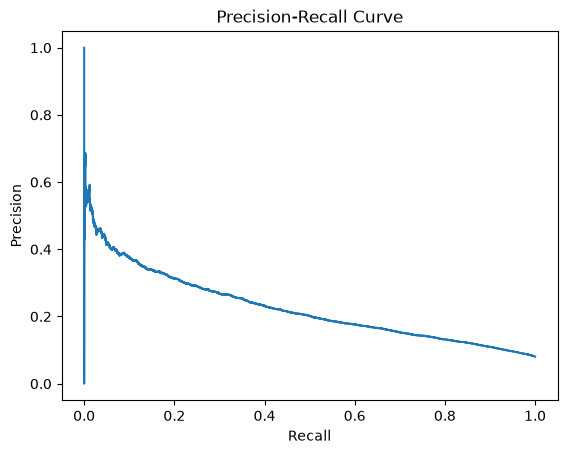

In [19]:
## Draw preision-recall curve

from sklearn.metrics import precision_recall_curve


precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


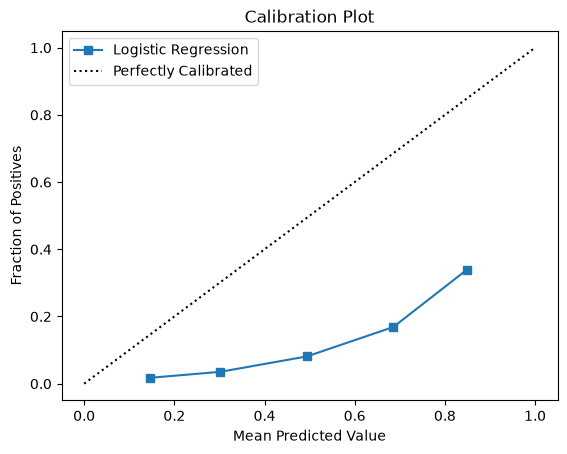

In [20]:
## Draw calibration curve
from sklearn.calibration import calibration_curve
fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_prob)
plt.plot(mean_predicted_value, fraction_of_positives, "s-", label="Logistic Regression")
plt.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")
plt.xlabel("Mean Predicted Value")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Plot")
plt.legend()
plt.show()


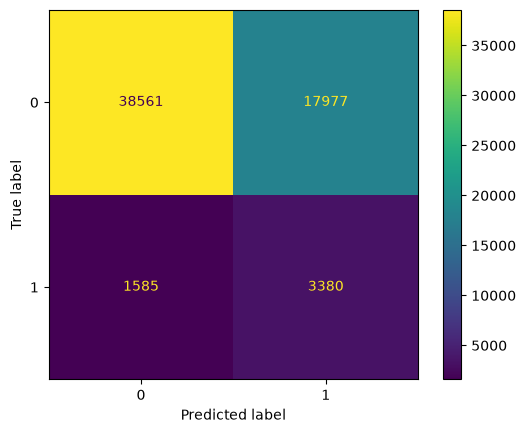

In [21]:
## Draw confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred))
disp.plot()
plt.show()


## Model Evaluation Summary

## Model Evaluation Summary

- **Cross-validation mean ROC-AUC:** `0.741`
- **Cross-validation standard deviation:** `0.0053`
- **Local test ROC-AUC:** `0.744`

The model has a reasonably good ability to rank defaulting applicants above non-defaulting applicants. The test ROC-AUC is very close to the cross-validation result, indicating stable generalization and no obvious overfitting. The low cross-validation standard deviation also shows that performance is consistent across different folds.

### Confusion Matrix

|                         | Predicted Non-default | Predicted Default |
|-------------------------|----------------------:|------------------:|
| **Actual Non-default**  | 38,561                | 17,977            |
| **Actual Default**      | 1,585                 | 3,380             |

- **True negatives:** `38,561` non-defaulting applicants were correctly classified.
- **False positives:** `17,977` non-defaulting applicants were incorrectly classified as default-risk.
- **False negatives:** `1,585` defaulting applicants were incorrectly classified as non-default.
- **True positives:** `3,380` defaulting applicants were correctly identified.

### Class 0 — Non-default Applicants

- **Precision:** `0.96`
- **Recall:** `0.68`
- **F1-score:** `0.80`
- **Support:** `56,538`

When the model predicts that an applicant will not default, it is correct approximately `96%` of the time. However, it identifies only about `68%` of all actual non-defaulting applicants because many safe applicants are incorrectly flagged as risky.

### Class 1 — Default-risk Applicants

- **Precision:** `0.16`
- **Recall:** `0.68`
- **F1-score:** `0.26`
- **Support:** `4,965`

The model detects approximately `68%` of applicants who actually default. However, only about `16%` of applicants predicted as default-risk actually default, meaning that the model produces many false-positive warnings.

### Overall Metrics

- **Accuracy:** `0.68`
- **Macro-average precision:** `0.56`
- **Macro-average recall:** `0.68`
- **Macro-average F1-score:** `0.53`
- **Weighted-average precision:** `0.90`
- **Weighted-average recall:** `0.68`
- **Weighted-average F1-score:** `0.75`

The weighted precision of `0.90` is strongly influenced by the much larger non-default class. It should not be interpreted as `90%` precision for identifying default-risk applicants.

### Overall Interpretation

The model provides useful ranking performance with a test ROC-AUC of approximately `0.744` and identifies around `68%` of actual default cases. Its main weakness is the large number of false positives, which results in only `16%` precision for the default class. The model may be useful when failing to detect a risky applicant is more costly than incorrectly flagging a safe applicant. The classification threshold can later be adjusted according to the business costs of false positives and false negatives.